# TPU generations and HBM memory budgeting

Runnable locally on CPU or on a Cloud TPU VM.

- Compare Google Cloud TPU generations (`v5e`, `v5p`, `v6e` Trillium, and Ironwood) by HBM capacity, HBM bandwidth, and MXU BF16 throughput.
- Calculate the Roofline ridge point (`bf16_tflops / bw_gbs`) in FLOPs per byte for each TPU generation.
- Compute training HBM (weights + gradients + Adam moments) and inference KV-cache HBM across `fp32`, `bfloat16`, and `int8`.
- Select the minimum single-host or Pod TPU slice that fits a given model's training state with activation headroom.

Provisioning and launching a TPU VM is only half the engineering job: if you pick the wrong TPU generation or miscalculate parameter + optimizer + KV-cache HBM bytes, your TPU experiment will either fail with `RESOURCE_EXHAUSTED: Out of memory` or under-utilize the Matrix Multiply Unit (MXU).

## The idea

Before scaling a Transformer or distributed job on TPU, compare per-chip HBM capacity and the BF16 compute-to-memory ridge point (`FLOP/byte`) across TPU generations (`v5e`, `v5p`, `v6e` Trillium, and Ironwood), and calculate the exact GiB budget for training state (weights, gradients, Adam moments) and inference KV cache across `fp32`, `bfloat16`, and `int8`.

## Connect MXU arithmetic intensity and HBM capacity to TPU slice sizing

Each TPU chip pairs a Matrix Multiply Unit (MXU) designed for high-throughput `bfloat16` / `int8` matrix multiplications with High Bandwidth Memory (HBM). A TPU v5e chip provides $16$ GiB of HBM at $819$ GB/s and $197$ TFLOP/s of `bfloat16` compute, giving a ridge-point balance of:
$$

\text{Ridge}_{\text{v5e}} = \frac{197 \times 10^{12}\text{ FLOP/s}}{819 \times 10^9\text{ B/s}} \approx 240.5\text{ FLOP/byte}

$$
Operations whose arithmetic intensity is below this ridge point (such as batch-$1$ autoregressive token decoding) are HBM-bandwidth bound; operations above it (such as large batched matmuls) are MXU-compute bound.

Before launching a run, you also need to verify HBM capacity. In mixed-precision Adam training, each parameter typically requires $12$ to $16$ bytes of persistent state (master `fp32` weights + `fp32` first and second Adam moments + `bf16` or `fp32` gradients), plus activation memory and any KV cache.

$$
\text{Throughput}_{\text{tok/s}} = \frac{B_{\text{global}} \times L_{\text{seq}}}{T_{\text{step}}}
$$

### TPU HBM-to-MXU dataflow and mixed-precision state budget

**Predict:** Which tensors stay in `float32` in HBM and which operands stream as `bfloat16` into the MXU?

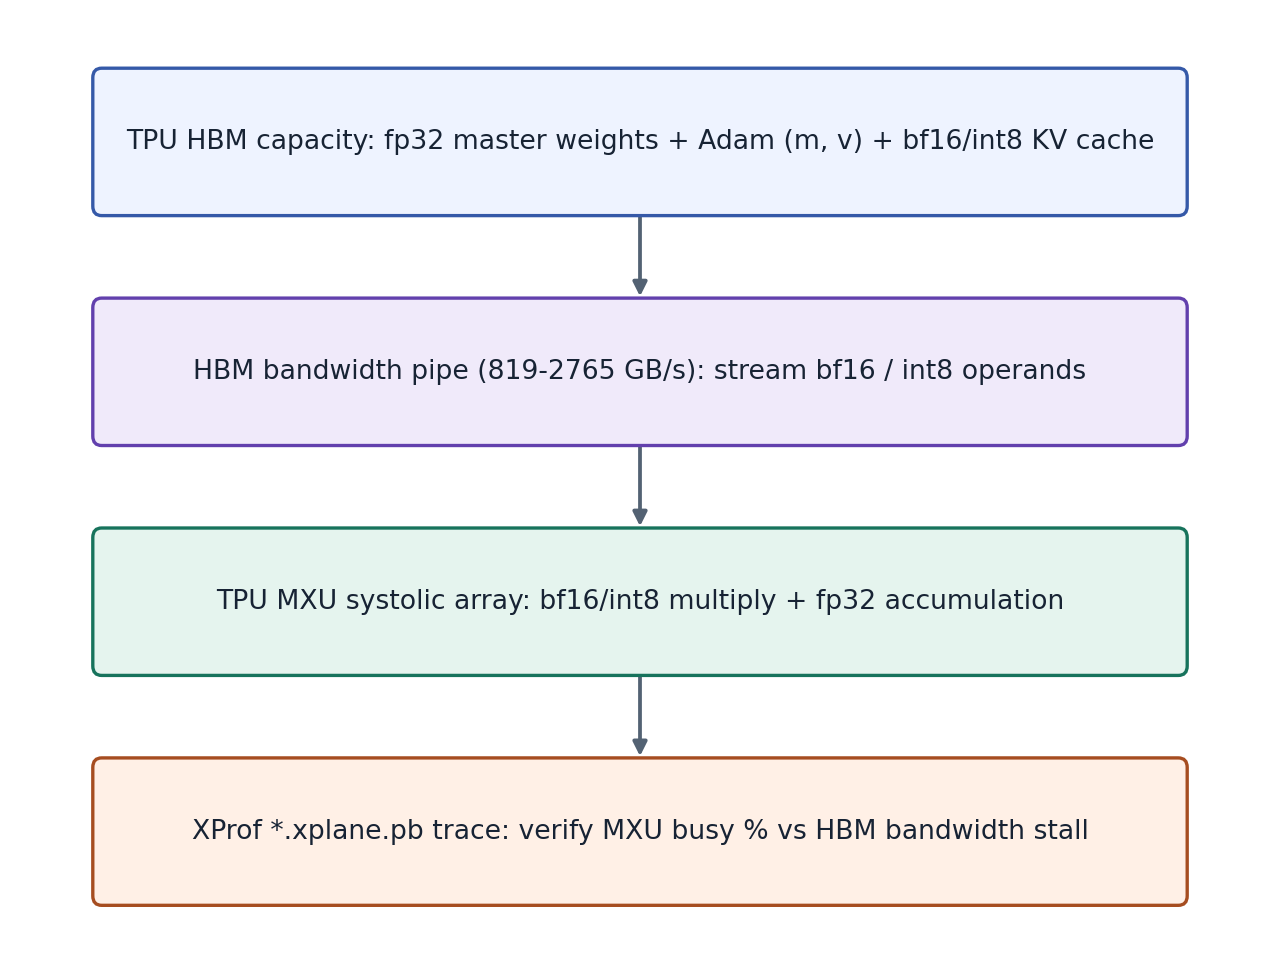

*Architecture and dataflow mechanism diagram.*

Read top to bottom: HBM stores master `fp32` parameters and Adam moments (`m`, `v`) alongside `bf16` activations and KV cache; operands are cast to `bf16` (or `int8`) to stream across the HBM bandwidth bottleneck into the MXU, which accumulates dot products in `fp32` before writing updated state back.

### Pause and reason

Why does a $7$B-parameter model's mixed-precision Adam training state (`~78.2` GiB before activations) fail with OOM on a single-host `v5litepod-4` (`64` GiB total HBM)?

<details><summary>Compare your reasoning</summary>

`4` TPU v5e chips provide `4 * 16 = 64` GiB of total HBM, which is smaller than the `~78.2` GiB needed just for parameters, gradients, and Adam moments. You need at least `v5litepod-8` (`128` GiB) or `v6e-4` (`128` GiB) with sharding across chips.

</details>

## 1. Compare TPU generations (`v5e`, `v5p`, `v6e`, Ironwood) and calculate HBM budgets

Published per-chip TPU specifications determine which slice fits your model:

- **TPU v5e (`v5litepod`)**: $16$ GiB HBM per chip, $819$ GB/s HBM bandwidth, $197$ BF16 TFLOP/s (`240.5` FLOP/byte ridge point). Single-host slices: `1`, `4` (`64` GiB), or `8` (`128` GiB) chips.
- **TPU v5p**: $95$ GiB HBM per chip, $2765$ GB/s HBM bandwidth, $459$ BF16 TFLOP/s (`166.0` FLOP/byte ridge point).
- **TPU v6e (Trillium)**: $32$ GiB HBM per chip, $1600$ GB/s HBM bandwidth, $918$ BF16 TFLOP/s (`573.8` FLOP/byte ridge point). Single-host slices: `1`, `4` (`128` GiB), or `8` (`256` GiB) chips.
- **TPU Ironwood (7th-gen scale)**: $192$ GiB HBM per chip, $7370$ GB/s HBM bandwidth.

**Run the TPU generation & HBM budgeting verifier on your TPU VM or workstation**

```bash
# Run the TPU generation & HBM budgeting verifier on your TPU VM or workstation
gcloud compute tpus tpu-vm scp public/exercises/tpu-03.py "$TPU_NAME":~/jax-tpu-lab/ --zone="$ZONE"
gcloud compute tpus tpu-vm ssh "$TPU_NAME" --zone="$ZONE" \
  --command="JAX_PLATFORMS=tpu ~/jax-tpu-lab/.venv/bin/python ~/jax-tpu-lab/tpu-03.py"
```

**Expected:** Prints the TPU ridge points (FLOP/byte) and the 7B and 1.5B training + KV-cache HBM budgets in GiB.

## Define TPU generation specs and compute Roofline ridge points

Create main.py with TPU_SPECS and calculate ridge_flops_per_byte for v5e, v5p, and v6e.

In [1]:
# Step 1 — Define TPU generation specs and compute Roofline ridge points: Dividing peak BF16 FLOP/s by HBM bandwidth (B/s) gives the minimum...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Initialize list `TPU_SPECS` for the stage values.
TPU_SPECS = [
    {"gen": "v5e", "hbm_gib": 16.0, "bw_gbs": 819.0, "bf16_tflops": 197.0},
    {"gen": "v5p", "hbm_gib": 95.0, "bw_gbs": 2765.0, "bf16_tflops": 459.0},
    {"gen": "v6e", "hbm_gib": 32.0, "bw_gbs": 1600.0, "bf16_tflops": 918.0},
]
# Iterate over `s` to step through the computation:
for s in TPU_SPECS:
    # Run `round` to compute `s['ridge_flops_per_byte']`.
    s["ridge_flops_per_byte"] = round((s["bf16_tflops"] * 1e12) / (s["bw_gbs"] * 1e9), 1)

Dividing peak BF16 FLOP/s by HBM bandwidth (B/s) gives the minimum FLOPs per byte needed to saturate the MXU.

## Estimate training-state and KV-cache HBM budgets across precisions

Append estimate_memory_gib and compare 7B vs 1.5B model memory footprints.

In [2]:
# Step 2 — Estimate training-state and KV-cache HBM budgets across precisions: Computing both training state and KV-cache GiB upfront prevents...
def estimate_memory_gib(params_billions, kv_tokens, layers=32, kv_heads=8, head_dim=128):
    # Compute `n_params` from `params_billions * 1e9`
    n_params = params_billions * 1e9
    # Compute `kv_elements` from `2.0 * layers * kv_tokens * kv_heads * head_dim`
    kv_elements = 2.0 * layers * kv_tokens * kv_heads * head_dim
    # Evaluate `1024 ** 3` and convert the result into Python scalar/collection `gib`.
    gib = float(1024 ** 3)
    # Return `{'fp32_train_state_gib': round(n_params * 16.0 / gib, 3), 'mixed_bf16_train_state_gib': round(n_params * 12.0 / gib, 3), 'kv_fp32_gib': round(kv_elements * 4.0 / gib, 3), 'kv_bf16_gib': round(kv_elements * 2.0 / gib, 3), 'kv_int8_gib': round(kv_elements * 1.0 / gib, 3)}` to the caller.
    return {
        "fp32_train_state_gib": round((n_params * 16.0) / gib, 3),
        "mixed_bf16_train_state_gib": round((n_params * 12.0) / gib, 3),
        "kv_fp32_gib": round((kv_elements * 4.0) / gib, 3),
        "kv_bf16_gib": round((kv_elements * 2.0) / gib, 3),
        "kv_int8_gib": round((kv_elements * 1.0) / gib, 3),
    }


# Run `estimate_memory_gib` to compute `budget_7b`.
budget_7b = estimate_memory_gib(params_billions=7.0, kv_tokens=8192)
# Run `estimate_memory_gib` to compute `budget_1p5b`.
budget_1p5b = estimate_memory_gib(params_billions=1.5, kv_tokens=4096)
# Assert that `budget_7b["mixed_bf16_train_state_gib"] > 64.0 and budget_7b["mixed_bf16_train_state_gib"] <`.
assert budget_7b["mixed_bf16_train_state_gib"] > 64.0 and budget_7b["mixed_bf16_train_state_gib"] < 128.0
# Assert invariant `budget_1p5b["mixed_bf16_train_state_gib"] < 64.0` holds
assert budget_1p5b["mixed_bf16_train_state_gib"] < 64.0
# Print the observed values to compare against the expected result.
print("TPU ridge points (FLOP/byte):", {s["gen"]: s["ridge_flops_per_byte"] for s in TPU_SPECS})
# Print diagnostic summary of the computed outputs.
print("7B memory budget (GiB):", budget_7b)
# Print diagnostic summary of the computed outputs.
print("1.5B memory budget (GiB):", budget_1p5b)

Computing both training state and KV-cache GiB upfront prevents OOM surprises when selecting between `v5litepod-4` (`64` GiB) and `v5litepod-8` / `v6e-4` (`128` GiB).

## Step 3: Verify invariants on the completed state

Run the final shape and numerical assertions to confirm the state built in Steps 1 and 2.

In [3]:
assert budget_7b["mixed_bf16_train_state_gib"] > 64.0 and budget_7b["mixed_bf16_train_state_gib"] < 128.0
assert budget_1p5b["mixed_bf16_train_state_gib"] < 64.0

Checking these invariants confirms the computation is ready for the full worked experiment.

## Run the example

In [4]:
# Step 1 — Define TPU generation specs and compute Roofline ridge points: Dividing peak BF16 FLOP/s by HBM bandwidth (B/s) gives the minimum...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Initialize list `TPU_SPECS` for the stage values.
TPU_SPECS = [
    {"gen": "v5e", "hbm_gib": 16.0, "bw_gbs": 819.0, "bf16_tflops": 197.0},
    {"gen": "v5p", "hbm_gib": 95.0, "bw_gbs": 2765.0, "bf16_tflops": 459.0},
    {"gen": "v6e", "hbm_gib": 32.0, "bw_gbs": 1600.0, "bf16_tflops": 918.0},
]
# Iterate over `s` to step through the computation:
for s in TPU_SPECS:
    # Run `round` to compute `s['ridge_flops_per_byte']`.
    s["ridge_flops_per_byte"] = round((s["bf16_tflops"] * 1e12) / (s["bw_gbs"] * 1e9), 1)


# Step 2 — Estimate training-state and KV-cache HBM budgets across precisions: Computing both training state and KV-cache GiB upfront prevents...
def estimate_memory_gib(params_billions, kv_tokens, layers=32, kv_heads=8, head_dim=128):
    # Compute `n_params` from `params_billions * 1e9`
    n_params = params_billions * 1e9
    # Compute `kv_elements` from `2.0 * layers * kv_tokens * kv_heads * head_dim`
    kv_elements = 2.0 * layers * kv_tokens * kv_heads * head_dim
    # Evaluate `1024 ** 3` and convert the result into Python scalar/collection `gib`.
    gib = float(1024 ** 3)
    # Return `{'fp32_train_state_gib': round(n_params * 16.0 / gib, 3), 'mixed_bf16_train_state_gib': round(n_params * 12.0 / gib, 3), 'kv_fp32_gib': round(kv_elements * 4.0 / gib, 3), 'kv_bf16_gib': round(kv_elements * 2.0 / gib, 3), 'kv_int8_gib': round(kv_elements * 1.0 / gib, 3)}` to the caller.
    return {
        "fp32_train_state_gib": round((n_params * 16.0) / gib, 3),
        "mixed_bf16_train_state_gib": round((n_params * 12.0) / gib, 3),
        "kv_fp32_gib": round((kv_elements * 4.0) / gib, 3),
        "kv_bf16_gib": round((kv_elements * 2.0) / gib, 3),
        "kv_int8_gib": round((kv_elements * 1.0) / gib, 3),
    }


# Run `estimate_memory_gib` to compute `budget_7b`.
budget_7b = estimate_memory_gib(params_billions=7.0, kv_tokens=8192)
# Run `estimate_memory_gib` to compute `budget_1p5b`.
budget_1p5b = estimate_memory_gib(params_billions=1.5, kv_tokens=4096)
# Assert that `budget_7b["mixed_bf16_train_state_gib"] > 64.0 and budget_7b["mixed_bf16_train_state_gib"] <`.
assert budget_7b["mixed_bf16_train_state_gib"] > 64.0 and budget_7b["mixed_bf16_train_state_gib"] < 128.0
# Assert invariant `budget_1p5b["mixed_bf16_train_state_gib"] < 64.0` holds
assert budget_1p5b["mixed_bf16_train_state_gib"] < 64.0
# Print the observed values to compare against the expected result.
print("TPU ridge points (FLOP/byte):", {s["gen"]: s["ridge_flops_per_byte"] for s in TPU_SPECS})
# Print diagnostic summary of the computed outputs.
print("7B memory budget (GiB):", budget_7b)
# Print diagnostic summary of the computed outputs.
print("1.5B memory budget (GiB):", budget_1p5b)

TPU ridge points (FLOP/byte): {'v5e': 240.5, 'v5p': 166.0, 'v6e': 573.8}
7B memory budget (GiB): {'fp32_train_state_gib': 104.308, 'mixed_bf16_train_state_gib': 78.231, 'kv_fp32_gib': 2.0, 'kv_bf16_gib': 1.0, 'kv_int8_gib': 0.5}
1.5B memory budget (GiB): {'fp32_train_state_gib': 22.352, 'mixed_bf16_train_state_gib': 16.764, 'kv_fp32_gib': 1.0, 'kv_bf16_gib': 0.5, 'kv_int8_gib': 0.25}


Expected: Prints the ridge-point FLOP/byte ratios for v5e (240.5), v5p (166.0), and v6e (573.8) along with the 7B and 1.5B memory budgets in GiB.

## Per-chip HBM capacity and ridge-point arithmetic intensity across TPU generations

Predict: How do per-chip HBM capacity (GiB) and the compute-to-memory ridge point (FLOP/byte) change across TPU `v5e`, `v5p`, and `v6e`?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Per-chip HBM capacity and ridge-point arithmetic intensity across TPU generations
# Construct dictionary `visual_data` with the structured fields for this stage.
visual_data = {
    'kind': 'bar',
    'labels': [s['gen'] for s in TPU_SPECS],
    'xlabel': 'Cloud TPU generation',
    'ylabel': 'GiB / (FLOP per byte)',
    'series': [
        {'label': 'HBM per chip (GiB)', 'y': [float(s['hbm_gib']) for s in TPU_SPECS]},
        {'label': 'BF16 ridge point (FLOP/byte)', 'y': [float(s['ridge_flops_per_byte']) for s in TPU_SPECS]},
    ],
}

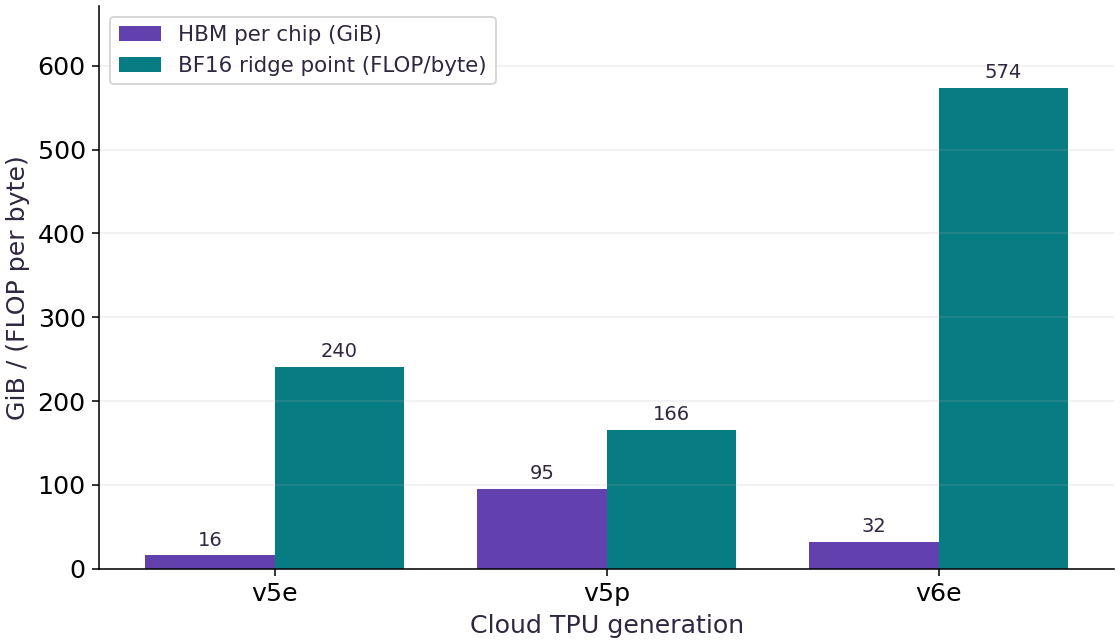

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis compares three Cloud TPU generations (`v5e`, `v5p`, and `v6e`). For each generation, the two bars show per-chip HBM capacity in GiB and the BF16 ridge point in FLOPs per byte (`bf16_tflops / bw_gbs`).

### Connect it to the computation

`v5p` maximizes HBM capacity per chip (`95` GiB) and lowers the ridge point (`166` FLOP/byte), while `v6e` doubles `v5e`'s HBM (`32` GiB vs `16` GiB) and reaches `918` BF16 TFLOP/s (`573.8` FLOP/byte ridge point), rewarding fused kernels and batch sizes that keep the MXU fed.

## Compare KV-cache memory across FP32, BF16, and INT8

Predict: By what factor does KV-cache memory drop when moving from FP32 to BF16 and INT8?

In [7]:
# Experiment — Compare KV-cache memory across FP32, BF16, and INT8: Halving bytes per element halves both the HBM capacity consumed...
# Assert that `np.isclose(budget_7b["kv_fp32_gib"], 2.0 * budget_7b["kv_bf16_gib"])`.
assert np.isclose(budget_7b["kv_fp32_gib"], 2.0 * budget_7b["kv_bf16_gib"])
# Assert that `np.isclose(budget_7b["kv_bf16_gib"], 2.0 * budget_7b["kv_int8_gib"])`.
assert np.isclose(budget_7b["kv_bf16_gib"], 2.0 * budget_7b["kv_int8_gib"])
# Print the observed values to compare against the expected result.
print("KV cache GiB (FP32 / BF16 / INT8):", budget_7b["kv_fp32_gib"], budget_7b["kv_bf16_gib"], budget_7b["kv_int8_gib"])

Expected: For 8192 tokens, KV cache drops from 2.0 GiB (FP32) to 1.0 GiB (BF16) and 0.5 GiB (INT8).

Halving bytes per element halves both the HBM capacity consumed by the KV cache and the HBM bytes read on every decode step.

## Verify how many v5e chips are needed to hold a 7B mixed-precision training state

Predict: Can a 4-chip TPU v5e slice (`64` GiB) hold a 7B parameter model's mixed-precision training state?

In [8]:
# Experiment — Verify how many v5e chips are needed to hold a 7B mixed-precision training state: Calculating state GiB upfront tells you immediately whether you...
v5e_chip_gib = 16.0
# Evaluate `np.ceil(budget_7b['mixed_bf16_train_state_gib'] / (v5e_chip_gib * 0.8))` and convert the result into Python scalar/collection `min_v5e_chips`.
min_v5e_chips = int(np.ceil(budget_7b["mixed_bf16_train_state_gib"] / (v5e_chip_gib * 0.8)))
# Print the observed values to compare against the expected result.
print("7B mixed train state GiB:", budget_7b["mixed_bf16_train_state_gib"], "Min v5e chips (at 80% HBM budget):", min_v5e_chips)
# Assert invariant `min_v5e_chips > 4 and min_v5e_chips <= 8` holds
assert min_v5e_chips > 4 and min_v5e_chips <= 8

Expected: A 7B mixed-precision state takes ~78.23 GiB, requiring at least an 8-chip v5litepod-8 slice (128 GiB HBM) when leaving 20% headroom for activations.

Calculating state GiB upfront tells you immediately whether you need `v5litepod-4` (`64` GiB) or `v5litepod-8` (`128` GiB) and FSDP sharding.

## Your exercise

Compute `estimate_memory_gib` for a `1.5`B parameter model with `4096` KV tokens and verify that its mixed-precision training state fits comfortably inside a single-host `v5litepod-4` (`64` GiB total HBM).

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `estimate_memory_gib(...)` — Call `estimate_memory_gib` with your updated parameters or inputs from this lesson's workspace.
- `budget(...)` — Call `budget` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Print the observed values to compare against the expected result.
2. Assert that `budget_check["mixed_bf16_train_state_gib"] < 20.0 and (budget_check["mixed_bf16_train_state_`.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Compute estimate_memory_gib for a 1.5B parameter model with 4096 KV...
budget_check = estimate_memory_gib(...)  # TODO: compute budget_check
# Print the observed values to compare against the expected result.
print("1.5B budget (GiB):", budget_check)
# Assert that `budget_check["mixed_bf16_train_state_gib"] < 20.0 and (budget_check["mixed_bf16_train_state_`.
assert budget_check["mixed_bf16_train_state_gib"]  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Compute estimate_memory_gib for a 1.5B parameter model with 4096 KV...
# budget_check = estimate_memory_gib(...)  # TODO: compute budget_check
# Print the observed values to compare against the expected result.
# print("1.5B budget (GiB):", budget_check)
# Assert that `budget_check["mixed_bf16_train_state_gib"] < 20.0 and (budget_check["mixed_bf16_train_state_`.
# assert budget_check["mixed_bf16_train_state_gib"]  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Compute estimate_memory_gib for a 1.5B parameter model with 4096 KV...
budget_check = estimate_memory_gib(params_billions=1.5, kv_tokens=4096)
# Print the observed values to compare against the expected result.
print("1.5B budget (GiB):", budget_check)
# Assert that `budget_check["mixed_bf16_train_state_gib"] < 20.0 and (budget_check["mixed_bf16_train_state_`.
assert budget_check["mixed_bf16_train_state_gib"] < 20.0 and (budget_check["mixed_bf16_train_state_gib"] + budget_check["kv_bf16_gib"]) < 64.0

## Compare arithmetic intensity against the TPU v5e and v6e ridge points · Foundations

Compute the arithmetic intensity (FLOPs/byte) of a `bfloat16` square matrix multiply of size $N = 1024$ (`2 * N^3` FLOPs divided by `3 * 2 * N^2` bytes) and check whether it exceeds the `v5e` ridge point.

Hint: For two `N x N` BF16 inputs and one BF16 output, arithmetic intensity simplifies to `N / 3.0` FLOPs/byte.

### How to write: Compare arithmetic intensity against the TPU v5e and v6e ridge points — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `points(...)` — Call `points` with your updated parameters or inputs from this lesson's workspace.
- `next(...)` — Call `next` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Compare arithmetic intensity against the TPU v5e and v6e ridge points (Foundations): At N=1024, arithmetic intensity is ~341.3 FLOP/byte, which...
2. Compute `arith_intensity` from `(2.0 * (n ** 3)) / (3.0 * 2.0 * (n ** 2))`
3. Run `next` to compute `v5e_ridge`.
4. Print the observed values to compare against the expected result.
5. Assert invariant `arith_intensity > v5e_ridge` holds

**Starter code scaffold (fill in the TODOs):**

```python
# Compare arithmetic intensity against the TPU v5e and v6e ridge points (Foundations): At N=1024, arithmetic intensity is ~341.3 FLOP/byte, which...
n = ...  # TODO: compute n
# Compute `arith_intensity` from `(2.0 * (n ** 3)) / (3.0 * 2.0 * (n ** 2))`
arith_intensity = ...  # TODO: compute arith_intensity
# Run `next` to compute `v5e_ridge`.
v5e_ridge = next(...)  # TODO: compute v5e_ridge
# Print the observed values to compare against the expected result.
print("Matmul N = ...  # TODO: compute print("Matmul N
# Assert invariant `arith_intensity > v5e_ridge` holds
assert arith_intensity  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Compare arithmetic intensity against the TPU v5e and v6e ridge points (Foundations): At N=1024, arithmetic intensity is ~341.3 FLOP/byte, which...
# n = ...  # TODO: compute n
# Compute `arith_intensity` from `(2.0 * (n ** 3)) / (3.0 * 2.0 * (n ** 2))`
# arith_intensity = ...  # TODO: compute arith_intensity
# Run `next` to compute `v5e_ridge`.
# v5e_ridge = next(...)  # TODO: compute v5e_ridge
# Print the observed values to compare against the expected result.
# print("Matmul N = ...  # TODO: compute print("Matmul N
# Assert invariant `arith_intensity > v5e_ridge` holds
# assert arith_intensity  # TODO: complete assertion check

## Reference reasoning

At N=1024, arithmetic intensity is ~341.3 FLOP/byte, which is above TPU v5e's ~240.5 FLOP/byte ridge point (compute-bound).

In [12]:
# Compare arithmetic intensity against the TPU v5e and v6e ridge points (Foundations): At N=1024, arithmetic intensity is ~341.3 FLOP/byte, which...
n = 1024
# Compute `arith_intensity` from `(2.0 * (n ** 3)) / (3.0 * 2.0 * (n ** 2))`
arith_intensity = (2.0 * (n ** 3)) / (3.0 * 2.0 * (n ** 2))
# Run `next` to compute `v5e_ridge`.
v5e_ridge = next(s["ridge_flops_per_byte"] for s in TPU_SPECS if s["gen"] == "v5e")
# Print the observed values to compare against the expected result.
print("Matmul N=1024 intensity:", round(arith_intensity, 1), "v5e ridge:", v5e_ridge)
# Assert invariant `arith_intensity > v5e_ridge` holds
assert arith_intensity > v5e_ridge

## Size a Trillium v6e-4 slice for a 7B training state · Transfer / diagnosis

Compute the total HBM (in GiB) of a 4-chip `v6e-4` slice (`32` GiB/chip) and check whether `budget_7b['mixed_bf16_train_state_gib']` fits inside `80%` of that slice's HBM.

Hint: Compare `budget_7b['mixed_bf16_train_state_gib']` with `4 * 32.0 * 0.8`.

### How to write: Size a Trillium v6e-4 slice for a 7B training state — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `state(...)` — Call `state` with your updated parameters or inputs from this lesson's workspace.
- `GiB(...)` — Call `GiB` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Compute `fits_v6e4` from `budget_7b["mixed_bf16_train_state_gib"] <= v6e4_usab...`
2. Print the observed values to compare against the expected result.
3. Assert invariant `fits_v6e4 is True` holds

**Starter code scaffold (fill in the TODOs):**

```python
# Size a Trillium v6e-4 slice for a 7B training state (Transfer / diagnosis): Because v6e doubles per-chip HBM to 32 GiB (128 GiB across 4...
v6e4_usable_gib = ...  # TODO: compute v6e4_usable_gib
# Compute `fits_v6e4` from `budget_7b["mixed_bf16_train_state_gib"] <= v6e4_usab...`
fits_v6e4 = ...  # TODO: compute fits_v6e4
# Print the observed values to compare against the expected result.
print("v6e-4 80% usable GiB:", v6e4_usable_gib, "Fits 7B state:", fits_v6e4)
# Assert invariant `fits_v6e4 is True` holds
assert fits_v6e4 is True  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Size a Trillium v6e-4 slice for a 7B training state (Transfer / diagnosis): Because v6e doubles per-chip HBM to 32 GiB (128 GiB across 4...
# v6e4_usable_gib = ...  # TODO: compute v6e4_usable_gib
# Compute `fits_v6e4` from `budget_7b["mixed_bf16_train_state_gib"] <= v6e4_usab...`
# fits_v6e4 = ...  # TODO: compute fits_v6e4
# Print the observed values to compare against the expected result.
# print("v6e-4 80% usable GiB:", v6e4_usable_gib, "Fits 7B state:", fits_v6e4)
# Assert invariant `fits_v6e4 is True` holds
# assert fits_v6e4 is True  # TODO: complete assertion check

## Reference reasoning

Because `v6e` doubles per-chip HBM to `32` GiB (`128` GiB across 4 chips, `102.4` GiB at 80% budget), a 7B sharded training state fits on a 4-chip `v6e-4` slice.

In [14]:
# Size a Trillium v6e-4 slice for a 7B training state (Transfer / diagnosis): Because v6e doubles per-chip HBM to 32 GiB (128 GiB across 4...
v6e4_usable_gib = 4 * 32.0 * 0.8
# Compute `fits_v6e4` from `budget_7b["mixed_bf16_train_state_gib"] <= v6e4_usab...`
fits_v6e4 = budget_7b["mixed_bf16_train_state_gib"] <= v6e4_usable_gib
# Print the observed values to compare against the expected result.
print("v6e-4 80% usable GiB:", v6e4_usable_gib, "Fits 7B state:", fits_v6e4)
# Assert invariant `fits_v6e4 is True` holds
assert fits_v6e4 is True

## Checkpoint

What does a TPU generation's Roofline ridge point (`bf16_tflops / bw_gbs` in FLOPs/byte) tell you about a kernel?

1. How many SSH keys can connect to the TPU VM
2. The minimum FLOPs performed per byte transferred from HBM required to become MXU compute-bound rather than HBM bandwidth-bound
3. How long `gcloud compute tpus tpu-vm create` takes to provision

## Diagnose

If your TPU job fails with `RESOURCE_EXHAUSTED: Out of memory while trying to allocate...`, compare your parameter + optimizer + activation + KV-cache byte estimate against per-chip HBM (`16` GiB on `v5e`, `32` GiB on `v6e`) and shard the state across chips (`NamedSharding` / FSDP) or reduce microbatch size.

## Evidence

Keep the TPU ridge-point table, 7B and 1.5B training/KV-cache HBM budgets, and minimum chip count calculation at an 80% HBM ceiling.

## Carry forward

- Size your TPU slice (`v5e`, `v5p`, `v6e`) from explicit HBM byte budgets for training state and KV caches before launching.
- Compare your workload's FLOPs/byte against the chip's ridge point to know whether fusion/quantization (bandwidth) or MXU tiling (compute) will speed it up.

## Primary references

- [Cloud TPU v5e, v5p, and v6e (Trillium) specifications](https://cloud.google.com/tpu/docs/v6e)
- [Cloud TPU performance guide](https://cloud.google.com/tpu/docs/performance-guide)